<a href="https://colab.research.google.com/github/mlemhadare/TX_DL/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Required to install packages
!pip install "numpy<2" medpy segmentation-models-3D


  Using cached keras-3.3.3-py3-none-any.whl.metadata (5.7 kB)
Using cached keras-3.3.3-py3-none-any.whl (1.1 MB)
  Attempting uninstall: keras
    Found existing installation: keras 3.13.0
    Uninstalling keras-3.13.0:
      Successfully uninstalled keras-3.13.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires keras>=3.10.0, but you have keras 3.3.3 which is incompatible.


## Import libraries

In [12]:
import os
import numpy as np
import nibabel as nib
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Cursor
import skimage.io as io
from math import ceil
import glob
import tensorflow as tf
import keras
from keras.models import load_model
import shutil

## Import your data

To import data from kaggle using API you should first have a kaggle account.

Upload kaggle.json to your Colab project: you can import `files` module from `google.colab`, and call `upload()` to launch a File Upload dialog and select the kaggle.json from your local machine. (Or just open the file explorer on the left and import your API key)

Update `KAGGLE_CONFIG_DIR` path to the current working directory. You can run `!pwd` to get the current working directory and assign the value to `os.environ['KAGGLE_CONFIG_DIR']` :

### Step 3: Set the `KAGGLE_CONFIG_DIR` Environment Variable

This tells Kaggle where to find your `kaggle.json` file. We previously set this, but it's good to ensure it's explicitly done before any Kaggle API calls.

In [ ]:
from google.colab import files
API_key = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:

!pwd


/content


In [ ]:

import os
current_dir = os.popen('pwd').read().strip()
os.environ['KAGGLE_CONFIG_DIR'] = current_dir

In [ ]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
 99% 4.13G/4.16G [01:26<00:01, 26.7MB/s]
100% 4.16G/4.16G [01:26<00:00, 51.6MB/s]


After these steps, you should be able to run the `!kaggle datasets download` command in cell `DFYYUIgX3aCq` successfully! The progress bar should also appear now.

In [ ]:
!unzip -q brats20-dataset-training-validation.zip

In [ ]:
# For space limitations don't keep unwanted large files or folders
!rm brats20-dataset-training-validation.zip

In [ ]:
!rm -r /content/BraTS2020_ValidationData

In [5]:
# Rename a specific file with a typo in the patient 355 folder (TrainingData, patient 355, segmentation file)
import os
os.rename("./data/BraTS2020_TrainingData/BraTS20_Training_355/W39_1998.09.19_Segm.nii",
          "./data/BraTS2020_TrainingData/BraTS20_Training_355/BraTS20_Training_355_seg.nii")

## **Loading/Visualizing our data**

#### To begin with let's get familiar with the data we are working with :

* The features (inputs)

    *  Each of the 4 sequences files are 3D images with a shape of (X, Y, Z).
    *  Brain scans (IRMs) are generally made of 4 sequences (Flair, T1, T1CE, T2).
    
        - **Flair** : Fluid Attenuated Inversion Recovery
        - **T1** : bla
        - **T1CE** : bla
        - **T2** : bla


- The labels (outputs)

    * 3D images called masks, that represents the tumor in a brain.
    * The values in the arrays indicates the label for each voxel:

        - 0: background
        - 1: core-tumor (necrosis)
        - 2: enhancing-tumor
        - 3: N/A
        - 4: Edema

#### Loading an image into an array

In [16]:
def load(filepath):
	"""
	Load a brain IRM with either of those extensions (.mha, .nii, .nii.gz, .npy)
	"""

	file_ext = filepath.split('.')[-1]
	name = filepath.split('.')[-2].split('/')[-1]

	# Load inputs data
	if file_ext == 'mha':
		image_data, image_header = medpy.io.load(filepath)
	elif file_ext == 'nii' or 'nii' + file_ext == 'niigz':
		image_data = nib.load(filepath).get_fdata()
	elif file_ext == 'npy':
		image_data = np.load("filename")
	else:
		print("Make sure to enter a supported file extension (.mha / .nii / .nii.gz / .npy)")
		return -1

	print("File information:")
	print("\t Input file name: {}".format(name))
	print("\t Input file type: {}".format(file_ext))
	print("\t Shape: {}".format(image_data.shape))

	print("----------------------------------------------------------------")
	return np.array(image_data)

#### Simple 2D plotting

In [17]:
def display2D(brain_data, seg_data=None, brain_color_map='bone', seg_color_map='jet'):

	if len(brain_data) < 0:
		# Return value of loadign image < -1 -> error occurred
		return -1
	if brain_data.ndim != 3:
		print("You should provide a 3 dimension array as brain data")
		return -1

	print("Type of brain data {}".format(type(brain_data)))

	if seg_data is not None:
		if len(seg_data) < 0:
			return -1
		if seg_data.ndim != 3:
			print("You should provide a 3 dimension array as seg data")
			return -1
		if brain_data.shape != seg_data.shape:
			print("Image data and Segmentation data do not have the same shape {}!={}".format(brain_data.shape, seg_data.shape))
			return -1

	print("Type of seg data {}".format(type(seg_data)))
	print("Brain and Segmentation data have shape {}".format(brain_data.shape))

	fig, ax = plt.subplots(1, 2)


	cut = random.randint(0, 2)

	if cut == 0:
		index = random.randint(0, brain_data.shape[cut]-1)
		if seg_data is not None:
			ax[0].set_title("YZ cut | layer: {}".format(index))
			ax[1].set_title("Segmentation/Mask")
			ax[0].imshow(brain_data[index, :, :], cmap=brain_color_map)
			ax[1].imshow(seg_data[index, :, :], cmap=seg_color_map)
		else:
			plt.title("YZ cut | layer: {}".format(index))
			plt.imshow(brain_data[index, :, :], cmap=brain_color_map)

	elif cut == 1:
		index = random.randint(0, brain_data.shape[cut]-1)
		if seg_data is not None:
			ax[0].set_title("XZ cut | layer: {}".format(index))
			ax[1].set_title("Segmentation/Mask")
			ax[0].imshow(brain_data[:, index, :], cmap=brain_color_map)
			ax[1].imshow(seg_data[:, index, :], cmap=seg_color_map)
		else:
			plt.title("XZ cut | layer: {}".format(index))
			plt.imshow(brain_data[:, index, :], cmap=brain_color_map)

	elif cut == 2:
		index = random.randint(0, brain_data.shape[cut]-1)
		if seg_data is not None:
			ax[0].set_title("XY cut | layer: {}".format(index))
			ax[1].set_title("Segmentation/Mask")
			ax[0].imshow(brain_data[:, :, index], cmap=brain_color_map)
			ax[1].imshow(seg_data[:, :, index], cmap=seg_color_map)
		else:
			plt.title("XY cut | layer: {}".format(index))
			plt.imshow(brain_data[:, :, index], cmap=brain_color_map)

File information:
	 Input file name: BraTS20_Training_001_t1ce
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_001_seg
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
Type of brain data <class 'numpy.ndarray'>
Type of seg data <class 'numpy.ndarray'>
Brain and Segmentation data have shape (240, 240, 155)


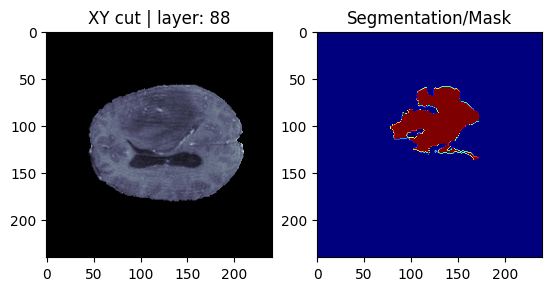

In [27]:
PATIENT = "001"
SEQUENCE = "t1ce"
image_path = "./data/BraTS2020_TrainingData/BraTS20_Training_{}/BraTS20_Training_{}_{}.nii".format(PATIENT, PATIENT, SEQUENCE)
seg_path = "./data/BraTS2020_TrainingData/BraTS20_Training_{}/BraTS20_Training_{}_seg.nii".format(PATIENT, PATIENT)
image_data = load(image_path)
seg_data = load(seg_path)
display2D(image_data, seg_data)

### Full 3D IRM display of a brain

To get a better overall view of the brain we should implement a function that gives us the posibility to look at every slice of the brain from any cut (angle) given.

In medical terms:
* Horizontal Cut (XY)
* Coronal Cut (XZ)
* Sagittal Cut (YZ)

>  **⚠️ Input shape should be (X, Y, Z)** (chose between flair, t1, t1ce and t2 for brain_data, and segmentation (seg) for seg_data)



In [28]:
def display3DCuts(brain_data, seg_data=None, brain_color_map='bone', seg_color_map='jet', seg_alpha=0.5):

	if len(brain_data) < 0:
		print("Brain data is empty")
		return -1
	if brain_data.ndim != 3:
		print("You should provide a 3 dimension array as brain data")
		return -1

	print("Type of brain data {}".format(type(brain_data)))

	if seg_data is not None:
		if len(seg_data) < 0:
			print("Segmentation data is empty")
			return -1
		if seg_data.ndim != 3:
			print("You should provide a 3 dimension array as seg data")
		if brain_data.shape != seg_data.shape:
			print("Image data and Segmentation data do not have the same shape {}!={}".format(brain_data.shape, seg_data.shape))
			return -1

	print("Type of seg data {}".format(type(seg_data)))
	print("Brain and Segmentation data have shape {}".format(brain_data.shape))

	# Plot with 3 Columns
	fig, ax = plt.subplots(1, 3)
	plt.subplots_adjust(bottom=0.25)

	# Create layers to place widgets
	axlayer_X = plt.axes([0.25, 0.2, 0.30, 0.03])
	axlayer_Y = plt.axes([0.25, 0.15, 0.30, 0.03])
	axlayer_Z = plt.axes([0.25, 0.1, 0.30, 0.03])

	# Get aprox the middle images for each of X Y Z
	half_X = ceil((brain_data.shape[0] - 1)/2)
	half_Y = ceil((brain_data.shape[1] - 1)/2)
	half_Z = ceil((brain_data.shape[2] - 1)/2)

	# Create Slider for each cut
	slider_X = Slider(axlayer_X, "Sagittal Cut", 0, brain_data.shape[0] - 1, valinit=half_X, valstep=1)
	slider_Y = Slider(axlayer_Y, "Coronal Cut", 0, brain_data.shape[1] - 1, valinit=half_Y, valstep=1)
	slider_Z = Slider(axlayer_Z, "Horizontal Cut", 0, brain_data.shape[2] - 1, valinit=half_Z, valstep=1)

	# Set title for each ax
	ax[0].set_title("{}/{}".format(half_X, brain_data.shape[0] - 1))
	ax[1].set_title("{}/{}".format(half_Y, brain_data.shape[1] - 1))
	ax[2].set_title("{}/{}".format(half_Z, brain_data.shape[2] - 1))

	# Update function for each respective slider and it's plot
	def update_X(val):
		layer = slider_X.val
		ax[0].imshow(brain_data[layer,:,:], cmap=brain_color_map)
		if seg_data is not None:
			ax[0].imshow(seg_data[layer,:,:], cmap=seg_color_map, alpha=seg_alpha*(seg_data[layer,:,:]>0))
		ax[0].set_title("{}/{}".format(layer, brain_data.shape[0] - 1))
		fig.canvas.draw_idle()

	def update_Y(val):
		layer = slider_Y.val
		ax[1].imshow(brain_data[:,layer,:], cmap=brain_color_map)
		if seg_data is not None:
			ax[1].imshow(seg_data[:,layer,:], cmap=seg_color_map, alpha=seg_alpha*(seg_data[:,layer,:]>0))
		ax[1].set_title("{}/{}".format(layer, brain_data.shape[1] - 1))
		fig.canvas.draw_idle()

	def update_Z(val):
		layer = slider_Z.val
		ax[2].imshow(brain_data[:,:,layer], cmap=brain_color_map)
		if seg_data is not None:
			ax[2].imshow(seg_data[:,:,layer], cmap=seg_color_map, alpha=seg_alpha*(seg_data[:,:,layer]>0))
		ax[2].set_title("{}/{}".format(layer, brain_data.shape[2] - 1))
		fig.canvas.draw_idle()


	# Update plot when interaction detected on slider
	slider_X.on_changed(update_X)
	slider_Y.on_changed(update_Y)
	slider_Z.on_changed(update_Z)


	# First display
	ax[0].imshow(brain_data[half_X,:,:], cmap=brain_color_map)
	ax[1].imshow(brain_data[:,half_Y,:], cmap=brain_color_map)
	ax[2].imshow(brain_data[:,:,half_Z], cmap=brain_color_map)
	if seg_data is not None:
		ax[0].imshow(seg_data[half_X,:,:], cmap=seg_color_map, alpha=seg_alpha*(seg_data[half_X,:,:]>0), vmin = 0)
		ax[1].imshow(seg_data[:,half_Y,:], cmap=seg_color_map, alpha=seg_alpha*(seg_data[:,half_Y,:]>0), vmin = 0)
		ax[2].imshow(seg_data[:,:,half_Z], cmap=seg_color_map, alpha=seg_alpha*(seg_data[:,:,half_Z]>0), vmin = 0)


	# Turn off all of the axis
	ax[0].axis('off')
	ax[1].axis('off')
	ax[2].axis('off')

	# Show plot
	plt.show()

Type of brain data <class 'numpy.ndarray'>
Type of seg data <class 'numpy.ndarray'>
Brain and Segmentation data have shape (240, 240, 155)


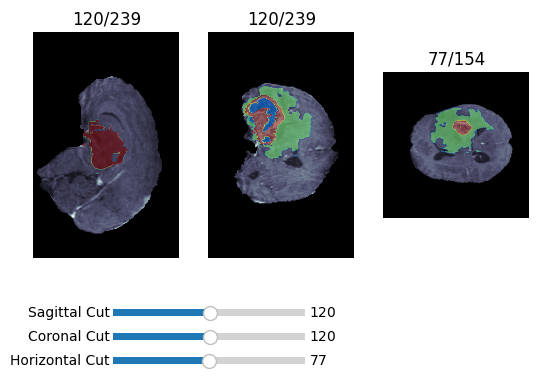

In [29]:
display3DCuts(image_data, seg_data) # Due to colab not being interactive with matplotlib interactive ploting not working for the moment

## Data processing

* Fit and transform the data we are working with

* Lots of infromation are not helpful and can lead to biases and a higher computing time.

    - The given data contains 4 sequences as mentionned above. Knowing that the T1ce is a contrast-enhanced version of the T1 we can get rid of the T1 sequence.
    - 0-valued (black) portions of the brain scans : reduce the shape of the data from 255x255x155 to 128x128x128 to "crop" the images taking out all the 0-valued pixels around the brain.

- Input shape of the model
    
    - S being the number of sequences: (X, Y, Z, S) -> (128, 128, 128, 3) (4 if T1 is included)

* Output shape of the model
    
    * (X, Y, Z, L) -> (128, 128, 128, 4) (4 for the 4 different labels we have)

In [30]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler

# Init a MinMaxScaler
scaler = MinMaxScaler()

### Process feature images (Brain)

Four step process:
* Scale each sequence array
* Combine 3 of the 4 sequence given (Flair, T1ce and T2) into one array
* Reshape/Crop it
* Save it as a numpy array (.npy)

Final result of a (128, 128, 128, 3) array  

In [31]:
def process_images(patient_dir_path, processed_dir_path="", file_ext='nii'):

	patient = patient_dir_path.split('/')[-1]

	image_flair = load(os.path.join(patient_dir_path, "{}_flair.{}".format(patient, file_ext)))
	image_flair = scaler.fit_transform(image_flair.reshape(-1, image_flair.shape[-1])).reshape(image_flair.shape)

	"""
	# Not useful
	test_image_t1 = load(os.path.join(patient_dir_path, "{}_t1.{}".format(patient, file_ext)))
	test_image_t1 = scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)
	"""

	image_t1ce = load(os.path.join(patient_dir_path, "{}_t1ce.{}".format(patient, file_ext)))
	image_t1ce = scaler.fit_transform(image_t1ce.reshape(-1, image_t1ce.shape[-1])).reshape(image_t1ce.shape)

	image_t2 = load(os.path.join(patient_dir_path, "{}_t2.{}".format(patient, file_ext)))
	image_t2 = scaler.fit_transform(image_t2.reshape(-1, image_t2.shape[-1])).reshape(image_t2.shape)

	if image_flair.shape == image_t1ce.shape == image_t2.shape and image_flair.ndim == image_t1ce.ndim == image_t2.ndim == 3 :
		# Stack 3 most important channel into 1 numpy array to feed the U-Net
		resulting_image = np.stack([image_flair,
									image_t1ce,
									image_t2], axis=3)

		# Crop the image from 240x240x155 to 128x128x128
		resulting_image = resulting_image[56:184, 56:184, 13:141] # Shape 128x128x128x3 (x4 if t1 included)

		np.save(os.path.join(processed_dir_path, "images", patient+".npy"), resulting_image)

	else:
		print("Channels don't have the same shape and/or are not conform to the standard IRM dim (X, X, X) for each channel")
		return -1

### Process label images (Mask)

Additionaly to croping the mask to 128, 128, 128. First refactoring all label 4 to 3 will help discarding a useless label.

And to gain a 4th dimension for the chosen label we should categorize the masks.

In [32]:
def process_mask(patient_dir_path, processed_dir_path="", file_ext='nii'):

	patient = patient_dir_path.split('/')[-1]

	mask = load(os.path.join(patient_dir_path, "{}_seg.{}".format(patient, file_ext)))
	mask = mask.astype(np.uint8)

	mask[mask==4] = 3
	mask = mask[56:184, 56:184, 13:141] # Shape 128x128x128

	mask = to_categorical(mask, num_classes=4)
	np.save(os.path.join(processed_dir_path, "mask", patient+".npy"), mask)


### Process patient

In [33]:
def process_patient(patient_dir_path, processed_path="", val=False):
    """
    Processes the images and the mask of a single patient by calling above functions
    """
    if val:
        process_mask(patient_dir_path, processed_path)
        process_images(patient_dir_path, processed_path)
        return True
    else:
        if random.randint(0,10) <= 8: # Get a ~80% chance of getting picked for training
            process_mask(patient_dir_path, processed_path)
            process_images(patient_dir_path, processed_path)
            return True
        return False

### Process dataset

In [34]:
def process_dataset(dataset_path=None, processed_path="", val=False):
    """
    Process an entire dataset with a specific schema
    """

    if dataset_path is None:
        print("Please enter a dataset path")
        return -1

    # Create the folders in which fill the processed images following schema:
    """ training_processed/
    ├─ images/
    │  ├─ BraTS20_Training_001.npy
    │  ├─ BraTS20_Training_002.npy
    │  ├─ BraTS20_Training_XXX.npy
    │  ├─ BraTS20_Training_YYY.npy
    ├─ mask/
    │  ├─ BraTS20_Training_001.npy
    │  ├─ BraTS20_Training_002.npy
    │  ├─ BraTS20_Training_XXX.npy
    │  ├─ BraTS20_Training_YYY.npy
    """
    #os.mkdir(processed_path)
    os.mkdir(processed_path+"/images")
    os.mkdir(processed_path+"/mask")

    # Processes each patient in the original dataset
    for dirname, patients, filenames in os.walk(dataset_path):
        for patient in patients:
            if process_patient(os.path.join(dirname, patient), processed_path, val):
                # uncomment the line below if you want to delete the raw data after processing it (convinient for online limitied storage)
                #shutil.rmtree(os.path.join(dirname, patient))
                pass

In [39]:
# Create the folder in which the processed training and validation data will be stored
!mkdir BraTS2020_ProcessedData

Un sous-r�pertoire ou un fichier BraTS2020_ProcessedData existe d�j�.


In [40]:
!mkdir BraTS2020_ProcessedData/train

La syntaxe de la commande n'est pas correcte.


In [37]:
!mkdir BraTS2020_ProcessedData/val

La syntaxe de la commande n'est pas correcte.


In [48]:
process_dataset("./data/BraTS2020_TrainingData/", "./data/BraTS2020_ProcessedData/train")

File information:
	 Input file name: BraTS20_Training_001\BraTS20_Training_001_seg
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_001\BraTS20_Training_001_flair
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_001\BraTS20_Training_001_t1ce
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_001\BraTS20_Training_001_t2
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_003\BraTS20_Training_003_seg
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:


In [ ]:
# !! Run the upper cell before !!
process_dataset("/content/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/", "/content/BraTS2020_ProcessedData/val", True)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
File information:
	 Input file name: BraTS20_Training_216_seg
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_216_flair
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_216_t1ce
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_216_t2
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_Training_053_seg
	 Input file type: nii
	 Shape: (240, 240, 155)
----------------------------------------------------------------
File information:
	 Input file name: BraTS20_

### DataGen

IRMs are medical images, being too big, let's generate batches of them to feed our NN.

In [49]:
def loadImageBis(image_dir, image_list):
    """
    Load .npy images in a given directory for a given list.
    Skips corrupted/empty files to avoid generator crashes.
    Returns float32 arrays to match model expectations.
    """

    images = []

    for image_name in image_list:
        if image_name.split(".")[-1] == "npy":
            file_path = os.path.join(image_dir, image_name)
            try:
                image = np.load(file_path)
            except ValueError as e:
                print(f"Skipping {file_path}: {e}")
                continue
            if image.size == 0:
                print(f"Skipping {file_path}: empty array")
                continue
            images.append(image)

    if not images:
        raise ValueError(f"No valid .npy files found in {image_dir} for list of length {len(image_list)}")

    return np.array(images, dtype=np.float32)


In [50]:
def imageLoader(image_dir, image_list, mask_dir, mask_list, batch_size):

    L = len(image_list)

    while True:

        batch_start = 0
        batch_end = batch_size

        while batch_start < L:
            limit = min(batch_end, L)


            X = loadImageBis(image_dir, image_list[batch_start:limit])
            Y = loadImageBis(mask_dir, mask_list[batch_start:limit])

            yield(X, Y)

            batch_start += batch_size
            batch_end += batch_size

## Model

Our model will be based on a U-Net shape. Well known for medical image segmentation.

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Dropout, Lambda
from keras.optimizers import Adam
from keras.metrics import MeanIoU

kernel_initializer =  'he_uniform' # the way we initialize our weights


def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, num_classes):

    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))

    s = inputs

    #Contraction path
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling3D((2, 2, 2))(c1)

    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling3D((2, 2, 2))(c2)

    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling3D((2, 2, 2))(c3)

    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling3D(pool_size=(2, 2, 2))(c4)

    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

    #Expansive path
    u6 = Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

    u7 = Conv3DTranspose(64, (2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

    u8 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

    u9 = Conv3DTranspose(16, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

    outputs = Conv3D(num_classes, (1, 1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])

    model.summary()

    return model

In [ ]:
train_img_dir = "/content/BraTS2020_ProcessedData/train/images/"
train_mask_dir = "/content/BraTS2020_ProcessedData/train/mask/"

val_img_dir = "/content/BraTS2020_ProcessedData/val/images/"
val_mask_dir = "/content/BraTS2020_ProcessedData/val/mask/"

# Keep lists stable and drop empty files to avoid generator crashes

def list_valid_npy(dir_path):
    return [f for f in sorted(os.listdir(dir_path)) if f.endswith(".npy") and os.path.getsize(os.path.join(dir_path, f)) > 0]

train_img_list = list_valid_npy(train_img_dir)
train_mask_list = list_valid_npy(train_mask_dir)

val_img_list = list_valid_npy(val_img_dir)
val_mask_list = list_valid_npy(val_mask_dir)

batch_size = 2

train_img_datagen = imageLoader(
    train_img_dir,
    train_img_list,
    train_mask_dir,
    train_mask_list,
    batch_size,
)

val_img_datagen = imageLoader(
    val_img_dir,
    val_img_list,
    val_mask_dir,
    val_mask_list,
    batch_size,
)


In [ ]:
!mkdir saved_models

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 22.5 MB/s eta 0:00:00


In [ ]:
import os
import math
import mlflow
import mlflow.keras

# Model dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_DEPTH = 128
IMG_CHANNELS = 3

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("tumorseg")

wt0, wt1, wt2, wt3 = 0.25, 0.25, 0.25, 0.25
import segmentation_models_3D as sm

# Use .keras extension to satisfy Keras 3 checkpoint format
ckpt_ext = "keras"

dice_loss = sm.losses.DiceLoss(class_weights=np.array([wt0, wt1, wt2, wt3]))
focal_loss = sm.losses.CategoricalFocalLoss(gamma=2.0)
total_loss = dice_loss + (1 * focal_loss)

metrics = [sm.metrics.FScore(), sm.metrics.IOUScore(threshold=0.5)]

LR = 0.0001
optim = keras.optimizers.Adam(LR)

epochs = 100
steps_per_epoch = math.ceil(len(train_img_list) / batch_size)
val_steps_per_epoch = math.ceil(len(val_img_list) / 2 * batch_size)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
)

mlflow.keras.autolog(log_models=True)

with mlflow.start_run(run_name="simple-unet-3d"):
    run_id = mlflow.active_run().info.run_id
    os.makedirs("saved_models", exist_ok=True)

    tb_log_dir = f"logs/run_{run_id}"
    cp_path = f"saved_models/brats_3d_simple_unet_{run_id}_epoch{{epoch:02d}}.{ckpt_ext}"

    cp_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=cp_path,
        save_weights_only=False,
        verbose=1,
    )

    tb_callback = tf.keras.callbacks.TensorBoard(tb_log_dir)

    model = simple_unet_model(
        IMG_HEIGHT=IMG_HEIGHT,
        IMG_WIDTH=IMG_WIDTH,
        IMG_DEPTH=IMG_DEPTH,
        IMG_CHANNELS=IMG_CHANNELS,
        num_classes=4,
    )

    model.compile(optimizer=optim, loss=total_loss, metrics=metrics)
    print(model.summary())
    print(model.input_shape)
    print(model.output_shape)

    mlflow.log_params({
        "lr": LR,
        "epochs": epochs,
        "batch_size": batch_size,
        "steps_per_epoch": steps_per_epoch,
        "val_steps_per_epoch": val_steps_per_epoch,
        "img_height": IMG_HEIGHT,
        "img_width": IMG_WIDTH,
        "img_depth": IMG_DEPTH,
        "img_channels": IMG_CHANNELS,
        "class_weights": [wt0, wt1, wt2, wt3],
        "loss": "DiceLoss+CategoricalFocalLoss",\
        "focal_gamma": 2.0,
    })

    history = model.fit(
        train_img_datagen,
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        verbose=1,
        validation_data=val_img_datagen,
        validation_steps=val_steps_per_epoch,
        callbacks=[cp_callback, tb_callback, reduce_lr, early_stop],
    )

    mlflow.log_artifacts(tb_log_dir)
    mlflow.log_artifacts("saved_models")


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/01/04 00:58:36 INFO mlflow.tracking.fluent: Experiment with name 'tumorseg' does not exist. Creating a new experiment.


Segmentation Models: using `keras` framework.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │      1,312 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv3d[0][0]      │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │      6,928 │ dropout[0][0]     │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │     13,856 │ max_pooling3d[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv3d_2[0][0]    │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │     27,680 │ dropout_1[0][0]   │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ conv3d_3[0][0]    │
│ (MaxPooling3D)      │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 32,    │     55,360 │ max_pooling3d_1[… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv3d_4[0][0]    │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 32, 32,    │    110,656 │ dropout_2[0][0]   │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 16, 16,    │          0 │ conv3d_5[0][0]    │
│ (MaxPooling3D)      │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 16, 16,    │    221,312 │ max_pooling3d_2[… │
│                     │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv3d_6[0][0]    │
│                     │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 16, 16,    │    442,496 │ dropout_3[0][0]   │
│                     │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 8, 8, 8,   │          0 │ conv3d_7[0][0]  

 Total params: 5,645,828 (21.54 MB)

...

 Non-trainable params: 0 (0.00 B)

None
(None, 128, 128, 128, 3)
(None, 128, 128, 128, 4)


2026/01/04 00:58:39 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'generator'>. Dataset logging skipped.
2026/01/04 00:58:39 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'generator'>. Dataset logging skipped.


Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - f1-score: 0.1504 - iou_score: 0.0634 - loss: 1.0029
Epoch 1: saving model to saved_models/brats_3d_simple_unet_2d0aede9dd9145ca85577b7004621d5f_epoch01.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 492s 3s/step - f1-score: 0.1508 - iou_score: 0.0639 - loss: 1.0028 - val_f1-score: 0.2565 - val_iou_score: 0.1990 - val_loss: 0.9450 - learning_rate: 1.0000e-04
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - f1-score: 0.3077 - iou_score: 0.2363 - loss: 0.9317
Epoch 2: saving model to saved_models/brats_3d_simple_unet_2d0aede9dd9145ca85577b7004621d5f_epoch02.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - f1-score: 0.3077 - iou_score: 0.2363 - loss: 0.9317 - val_f1-score: 0.3190 - val_iou_score: 0.2765 - val_loss: 0.9283 - learning_rate: 1.0000e-04
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - f1-score: 0.3435 - iou_score: 0.2669 - loss: 0.9233
Epoch 3: saving model to saved_models/brats_3d_simple_unet_2d0aede9dd9145ca85577b7004621d5

2026/01/04 11:55:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/04 11:55:41 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpangtnqzq/model, flavor: keras). Fall back to return ['keras==3.3.3']. Set logging level to DEBUG to see the full traceback. 


In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
iou = history.history['iou_score']
val_iou = history.history['val_iou_score']

plt.plot(epochs, iou, 'y', label='Training iou score')
plt.plot(epochs, val_iou, 'r', label='Validation iou score')
plt.title('Training and validation iou scores')
plt.xlabel('Epochs')
plt.ylabel('iou')
plt.legend()
plt.show()

In [ ]:
f_score = history.history['f1-score']
val_f_score = history.history['val_f1-score']

plt.plot(epochs, f_score, 'y', label='Training f1-score')
plt.plot(epochs, val_f_score, 'r', label='Validation f1-score')
plt.title('Training and validation f1 scores')
plt.xlabel('Epochs')
plt.ylabel('f1-score')
plt.legend()
plt.show()

## Exemple


Brain tumor segmentation on a patient in the validation dataset.

In [ ]:

img_num = "001"

test_img = np.load("/content/BraTS2020_ProcessedData/val/images/BraTS20_Training_"+str(img_num)+".npy")

test_mask = np.load("/content/BraTS2020_ProcessedData/val/mask/BraTS20_Training_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)

my_model = load_model('/content/saved_models/brats_3d_simple_unet_50.h5',
                      custom_objects={'dice_loss_plus_1focal_loss': total_loss,
                                      'iou_score':sm.metrics.IOUScore(threshold=0.5),
                                      'f1-score':sm.metrics.FScore()})

test_prediction = my_model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]


#n_slice=random.randint(0, test_prediction_argmax.shape[2])
n_slice = 50
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='bone')
plt.subplot(232)
plt.title('Ground truth')
plt.imshow(test_mask_argmax[:,:,n_slice], cmap='jet')
plt.subplot(233)
plt.title('Prediction')
plt.imshow(test_prediction_argmax[:,:, n_slice], cmap='jet')
plt.show()